# T1 - rotation-period census

Q17 limb A asks whether the encoder can recover rotation periods it never sees a full cycle of.
Before T2 fits anything, this notebook counts how many labelled rotators actually sit beyond the
model's input baseline, in each population T2 could score on.

The model's input baseline:

    seq_len * window_size * cadence = 16 * 256 * 2 min = 8192 min = 5.69 d

    P_rot <= 5.69 d  ->  at least one full cycle sits inside one sequence
    P_rot >  5.69 d  ->  no tensor the encoder sees contains a full cycle, yet TARS still labels it

The 4 x 1024 Stage-0b pack and the 16 x 256 trained subdivision span the same physical time, so the
baseline is 5.69 d under either geometry.

TARS is a single-sector survey (~27 d) reliable to 25 d, so the band 5.7-25 d is exactly the set of
stars where a label exists for a quantity the model cannot directly observe. That band is T2's target.

**Decision rule, stated before the counts (reporting granularity only; the G-rot claim gate is
unchanged):**

| n in 5.7-13 d, r8_scoreable pool | how T2 reports the beyond-baseline band |
|---|---|
| >= 1000 | the two beyond-baseline buckets are reported separately |
| 100 - 1000 | the two beyond-baseline buckets are merged into one 5.7-25 d stratum |
| < 100 | the band is a footnote, not a result |

## Populations

| population | definition | why T2 cares |
|---|---|---|
| `corpus_with_windows` | every corpus star with at least one NaN-free window (`experiments/r8_fullpool/r8_pool.parquet`) | the label ceiling: the most rotators that could ever be scored |
| `v1_subset` | the frozen 13,470-star probe subset (train 9,428 / val 2,021 / test 2,021) | where the published v1 rotation number lives |
| `r8_scoreable` | `corpus_with_windows` minus the probe's train and val splits, i.e. roles `added` + `existing_test` | every star R8 already cached mu for, so T2 can reach it without refitting the frozen probe |

R8's `survey_matched` is a **scoring population, not a star set**: its positives are only the
2,021-star subset-test split (positives never expand, 85% are locked in probe-train) and its negatives
are redrawn per draw to the corpus base rate. Censusing it would just re-census the test split, so it
is reported separately at the end rather than as a census column, and `r8_scoreable` stands in as the
survey-scale star set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root = Path.cwd()
while not (root / "labels" / "variability_labels_star.csv").exists(): # src/labels also exists, so anchor on the file
    root = root.parent

labels = pd.read_csv(root / "labels" / "variability_labels_star.csv")
pool = pd.read_parquet(root / "experiments" / "r8_fullpool" / "r8_pool.parquet")
subset = pd.read_parquet(root / "processed" / "subset" / "subset_tics.parquet")

populations = {}
populations["corpus_with_windows"] = set(pool["tic_id"])
populations["v1_subset"] = set(subset["tic_id"])
populations["r8_scoreable"] = set(pool.loc[pool["role"].isin(["added", "existing_test"]), "tic_id"])

sizes = []
for name in populations:
    sizes.append({"population": name, "n_stars": len(populations[name])})
pd.DataFrame(sizes)

,population,n_stars
0,corpus_with_windows,119754
1,v1_subset,13470
2,r8_scoreable,108305


The three population sizes and the rotator total are published numbers
(`experiments/r8_fullpool/README.md`, project `CLAUDE.md`), so they are asserted in-cell rather than
trusted: if a label regeneration moves them, this notebook fails instead of quietly reporting a
different corpus.

In [2]:
assert len(populations["corpus_with_windows"]) == 119754
assert len(populations["v1_subset"]) == 13470
assert len(populations["r8_scoreable"]) == 108305
assert int(labels["rotation"].sum()) == 25369
assert labels["rotation_period"].notna().sum() == int(labels["rotation"].sum())
print("ok: population sizes and rotator total agree with r8_fullpool/README.md and CLAUDE.md")

ok: population sizes and rotator total agree with r8_fullpool/README.md and CLAUDE.md


## Buckets

Four buckets that tile the period axis exactly, edges left-open / right-closed:

    (0, 2]        <=2 d      strictly resolvable (SpinSpotter: reliable to ~baseline/3)
    (2, 5.69]     2-5.7 d    resolvable, at least one full cycle inside a sequence
    (5.69, 13]    5.7-13 d   beyond the MODEL's baseline, well inside TARS's
    (13, inf)     >=13 d     beyond the model's baseline, approaching TARS's own 25 d limit

Two boundary facts the table has to carry rather than hide:

1. ADR-0004 caps the v1 primary rotation metric at **P <= 5.0 d**, not 5.69 d. The two disagree, so
   `n_le_5d` is reported beside the buckets; the difference is exactly the population T3 must
   reconcile (Q13 proposes enforcing the cap, T2 deliberately crosses it).
2. `docs/labels-sources.md` states the TARS range as 0.5-25 d. The label file actually spans
   0.1-26.6 d, so `n_gt_25d` guards the upper end: any star past TARS's own reliability limit would be
   limited by the label rather than by the model, and must not be scored silently.

In [3]:
baseline_days = 16 * 256 * 2 / 60 / 24 # seq_len * window_size * 2-min cadence at the 256 geometry, in days
bucket_edges = [0.0, 2.0, baseline_days, 13.0, np.inf]
bucket_names = ["<=2 d", "2-5.7 d", "5.7-13 d", ">=13 d"]

rotators = labels.loc[labels["rotation"] == 1, ["tic_id", "rotation_period"]].copy()
rotators["bucket"] = pd.cut(rotators["rotation_period"], bins=bucket_edges, labels=bucket_names)

rows = []
for name in populations:
    members = rotators[rotators["tic_id"].isin(populations[name])]
    counts = members["bucket"].value_counts()
    row = {"population": name,
           "n_stars": len(populations[name]),
           "n_rot": len(members),
           "n_tars_null": len(populations[name]) - len(members)}
    for bucket in bucket_names:
        row[bucket] = int(counts.get(bucket, 0))
    row["beyond_5p7_to_25"] = int(((members["rotation_period"] > baseline_days) & (members["rotation_period"] <= 25.0)).sum())
    row["n_le_5d"] = int((members["rotation_period"] <= 5.0).sum())
    row["n_gt_25d"] = int((members["rotation_period"] > 25.0).sum())
    rows.append(row)

census = pd.DataFrame(rows)
census

,population,n_stars,n_rot,n_tars_null,<=2 d,2-5.7 d,5.7-13 d,>=13 d,beyond_5p7_to_25,n_le_5d,n_gt_25d
0,corpus_with_windows,119754,14927,104827,6469,3779,3459,1220,4679,9745,0
1,v1_subset,13470,1138,12332,788,192,122,36,158,959,0
2,r8_scoreable,108305,13969,94336,5807,3616,3357,1189,4546,8936,0


### Reading the table

    beyond_5p7_to_25 = rotators whose TARS period exceeds the model's input baseline but stays
                       inside TARS's single-sector reliability limit
                     = the population Q17 limb A is about

Three things the numbers settle:

1. **The band has an n.** 4,679 corpus rotators sit beyond the model's baseline, 4,546 of them
   reachable in `r8_scoreable`. The pre-registered rule asked for >= 1000 in 5.7-13 d on that pool;
   the count is 3,357, so **T2 reports the two beyond-baseline buckets separately**, not merged.
2. **The v1 subset cannot carry this analysis.** It holds 158 beyond-baseline rotators in total, and
   the `survey_matched` table below shows only 25 of them sit in the test split. T2 must score on
   `r8_scoreable`, where R8's cached mu already exists; the v1 subset is the contrast row, not the
   measurement.
3. **`n_gt_25d` is 0 everywhere.** The 0.1-26.6 d span of the label file does not survive the
   corpus-with-windows cut, so nothing is scored past TARS's own reliability limit and the `>=13 d`
   bucket is bounded above by the data, not by a choice.

### What the table does not say

`n_tars_null` counts corpus stars **absent from TARS**, which means "no rotation period was published
for this star", not "TARS analysed it and found nothing". The analysed-and-null set lives in
`tars_table_4` (~40 GB, unused, not v1 scope). So `n_tars_null` is an upper bound on the true
non-rotators, and it contains the very stars a discovery claim would be made from: a model-positive /
TARS-null star is counted here as a negative today. That is the circularity T0 documents.

The bucket counts are **label** counts. They say a target exists at this n, not that it is learnable.
Whether anything recovered in the beyond-baseline band is period inference rather than activity
amplitude is T2's question, and its amplitude-only control is what separates the two.

## The `survey_matched` positive count, for the record

R8 scores `survey_matched` on subset-test positives only. Reporting its bucketed positive count keeps
the name honest and shows why it could not serve as the census column.

In [4]:
test_tics = set(subset.loc[subset["split"] == "test", "tic_id"])
survey_matched_positives = rotators[rotators["tic_id"].isin(test_tics)]
survey_matched_positives["bucket"].value_counts().reindex(bucket_names).rename_axis("bucket").to_frame("n_positives")

,n_positives
bucket,
<=2 d,126
2-5.7 d,29
5.7-13 d,20
>=13 d,5


## Distribution

One step histogram per population on a log count axis, with the two boundaries that matter marked:
the model's 5.69 d input baseline and TARS's 25 d single-sector limit. `corpus_with_windows` and
`r8_scoreable` differ only by the 11,449 fenced-off probe train/val stars, so they should lie almost
on top of each other; `v1_subset` is ~11x smaller and is expected to sit an order of magnitude below.

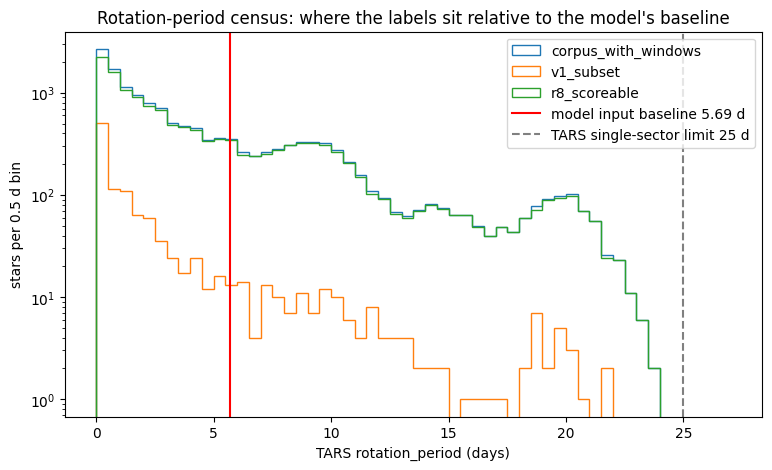

In [5]:
plt.figure(figsize=(9, 5))
for name in populations:
    members = rotators[rotators["tic_id"].isin(populations[name])]
    plt.hist(members["rotation_period"], bins=np.arange(0, 27.5, 0.5), histtype="step", label=name)
plt.axvline(baseline_days, color="red", label="model input baseline 5.69 d")
plt.axvline(25.0, color="grey", linestyle="--", label="TARS single-sector limit 25 d")
plt.yscale("log")
plt.xlabel("TARS rotation_period (days)")
plt.ylabel("stars per 0.5 d bin")
plt.title("Rotation-period census: where the labels sit relative to the model's baseline")
plt.legend()
plt.show()

### Reading the figure

`corpus_with_windows` and `r8_scoreable` are indistinguishable at this resolution, which is the point:
fencing off the probe's train and val splits costs almost nothing in beyond-baseline coverage, so T2
loses nothing by scoring on the pool where the frozen probe stays valid.

The distribution is not a smooth decay past the baseline. Counts fall to a local minimum near 7 d,
recover into a broad hump around 9-11 d, dip near 15-16 d, and rise again into a second hump near
19-21 d before terminating at 23.6 d. Two readings, and this notebook cannot separate them:

    astrophysical  ->  real populations (e.g. a slow-rotator sequence) sitting at those periods
    instrumental   ->  TARS alias / detection structure at a fraction of the ~27 d sector

Either way it matters for T2: the beyond-baseline band is not uniformly populated, so a per-bucket
score is a mixture over these humps and a monotonic-degradation reading must not be over-fitted to
their edges.

The `v1_subset` curve falls off far faster than the other two beyond ~6 d and reaches counts of 1-2
per bin past 13 d. That is the same shortfall the table reported, seen as a shape.

## Hand-off to T2

Long-form CSV, one row per (population, bucket), with the population-level scalars carried on every
row so T2 can stratify without re-deriving the pools.

In [6]:
tidy = census.melt(
    id_vars=["population", "n_stars", "n_rot", "n_tars_null", "beyond_5p7_to_25", "n_le_5d", "n_gt_25d"],
    value_vars=bucket_names,
    var_name="bucket",
    value_name="n")
tidy["frac_of_rot"] = tidy["n"] / tidy["n_rot"]
tidy.to_csv(root / "experiments" / "t1_rotation_census.csv", index=False)
tidy

,population,n_stars,n_rot,n_tars_null,beyond_5p7_to_25,n_le_5d,n_gt_25d,bucket,n,frac_of_rot
0,corpus_with_windows,119754,14927,104827,4679,9745,0,<=2 d,6469,0.433376
1,v1_subset,13470,1138,12332,158,959,0,<=2 d,788,0.692443
2,r8_scoreable,108305,13969,94336,4546,8936,0,<=2 d,5807,0.415706
3,corpus_with_windows,119754,14927,104827,4679,9745,0,2-5.7 d,3779,0.253165
4,v1_subset,13470,1138,12332,158,959,0,2-5.7 d,192,0.168717
5,r8_scoreable,108305,13969,94336,4546,8936,0,2-5.7 d,3616,0.258859
6,corpus_with_windows,119754,14927,104827,4679,9745,0,5.7-13 d,3459,0.231728
7,v1_subset,13470,1138,12332,158,959,0,5.7-13 d,122,0.107206
8,r8_scoreable,108305,13969,94336,4546,8936,0,5.7-13 d,3357,0.240318
9,corpus_with_windows,119754,14927,104827,4679,9745,0,>=13 d,1220,0.081731
